In [1]:
import pandas as pd
import pickle
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
data = pd.read_csv("../data/mobixa_intents_clean.csv")

# If your notebook is in the same folder:
# data = pd.read_csv("mobixa_intents_clean.csv")

data.head()

,text,intent,response,lowercase,no_punctuation,tokens,no_stopwords,stemmed,lemmatized,processed_text
0,Catch you later,goodbye,Response for goodbye.,catch you later,catch you later,"['catch', 'you', 'later']","['catch', 'later']","['catch', 'later']","['catch', 'later']",catch later
1,Hi,greeting,Response for greeting.,hi,hi,['hi'],['hi'],['hi'],['hi'],hi
2,Good morning,greeting,Response for greeting.,good morning,good morning,"['good', 'morning']","['good', 'morning']","['good', 'morn']","['good', 'morning']",good morning
3,Cost of Redmi Note 14,price_query,Response for price_query.,cost of redmi note 14,cost of redmi note 14,"['cost', 'of', 'redmi', 'note', '14']","['cost', 'redmi', 'note', '14']","['cost', 'redmi', 'note', '14']","['cost', 'redmi', 'note', '14']",cost redmi note 14
4,Availability of Galaxy S24,availability,Response for availability.,availability of galaxy s24,availability of galaxy s24,"['availability', 'of', 'galaxy', 's24']","['availability', 'galaxy', 's24']","['avail', 'galaxi', 's24']","['availability', 'galaxy', 's24']",availability galaxy s24


In [ ]:
with open("../models/tokenizer.pkl","rb") as file:
    tokenizer = pickle.load(file)



In [4]:
X = tokenizer.texts_to_sequences(data["processed_text"])

max_length = max(len(sentence) for sentence in X)

X = pad_sequences(
    X,
    maxlen=max_length,
    padding="post"
)

print(X.shape)

(1000, 7)


In [5]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(data["intent"])

y = to_categorical(y)

print(y.shape)

(1000, 10)


In [6]:
with open("../models/label_encoder.pkl","wb") as file:
    pickle.dump(label_encoder,file)

print("Label Encoder Saved")

Label Encoder Saved


In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

In [8]:
model = Sequential()

model.add(
    Embedding(
        input_dim=len(tokenizer.word_index)+1,
        output_dim=128,
        input_length=max_length
    )
)

model.add(
    LSTM(128)
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(
        y.shape[1],
        activation="softmax"
    )
)

c:\Users\10mih\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(

    X_train,

    y_train,

    epochs=20,

    batch_size=16,

    validation_split=0.20,

    verbose=1

)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.1766 - loss: 2.2247 - val_accuracy: 0.3125 - val_loss: 1.8822
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4156 - loss: 1.3722 - val_accuracy: 0.8500 - val_loss: 0.8118
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8094 - loss: 0.5717 - val_accuracy: 0.8938 - val_loss: 0.3667
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9500 - loss: 0.2353 - val_accuracy: 0.9438 - val_loss: 0.1340
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9781 - loss: 0.0981 - val_accuracy: 1.0000 - val_loss: 0.0364
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9922 - loss: 0.0455 - val_accuracy: 0.9875 - val_loss: 0.0352
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9906 - loss: 0.0459 - val_accuracy: 0.9875 - val_loss: 0.0411
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9969 - loss: 0.0233 - val_accuracy: 1.0000 - v

In [12]:
loss, accuracy = model.evaluate(

    X_test,

    y_test

)

print("Test Accuracy :", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 1.0000 - loss: 9.9251e-04
Test Accuracy : 1.0


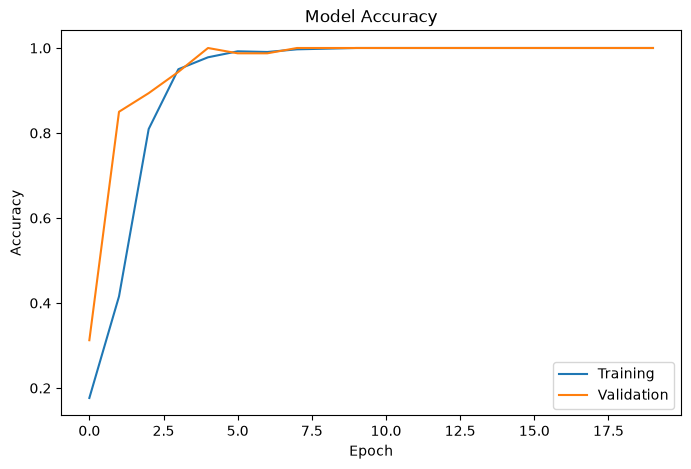

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],label="Training")

plt.plot(history.history["val_accuracy"],label="Validation")

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

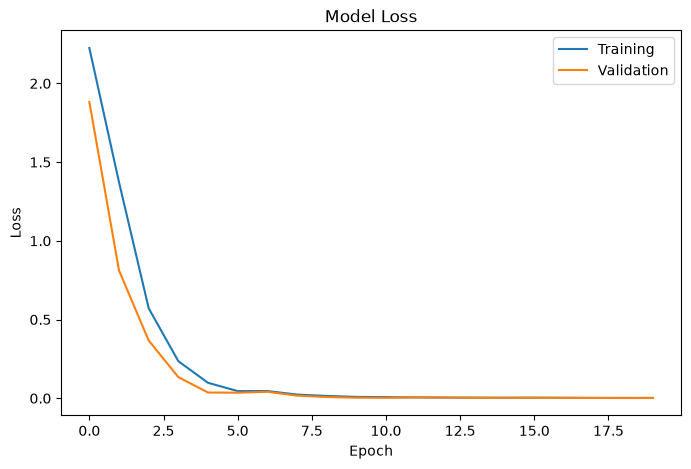

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],label="Training")

plt.plot(history.history["val_loss"],label="Validation")

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [15]:
model.save("../models/intent_classifier_dl.keras")

print("Deep Learning Model Saved Successfully")

Deep Learning Model Saved Successfully


In [16]:
text = ["What is the price of Samsung Galaxy S24?"]

sequence = tokenizer.texts_to_sequences(text)

sequence = pad_sequences(

    sequence,

    maxlen=max_length,

    padding="post"

)

prediction = model.predict(sequence)

intent = label_encoder.inverse_transform(

    [np.argmax(prediction)]

)

print("Predicted Intent :",intent[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
Predicted Intent : price_query


In [17]:
examples = [

    "Hello",

    "Price of iPhone 15",

    "Compare Samsung and Apple",

    "Do you repair Oppo phones?",

    "Bye"

]

for sentence in examples:

    seq = tokenizer.texts_to_sequences([sentence])

    seq = pad_sequences(

        seq,

        maxlen=max_length,

        padding="post"

    )

    prediction = model.predict(seq)

    intent = label_encoder.inverse_transform(

        [np.argmax(prediction)]

    )

    print(sentence," ---> ",intent[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Hello  --->  greeting
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Price of iPhone 15  --->  price_query
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Compare Samsung and Apple  --->  comparison
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Do you repair Oppo phones?  --->  phone_search
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Bye  --->  goodbye
